In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


I0000 00:00:1779575139.558867    9766 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779575139.960463    9766 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779575142.685480    9766 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:

spect = np.load('spectrums.npy')
label = pd.read_csv('FM_Parameter_Table.csv')
auxill = pd.read_csv('AuxillaryTable.csv')

wavelengths = spect[ 0, :, 0]
spectrum = spect[:, :, 1]
unc = spect[:, :,2]

wavelengths.shape

(52,)

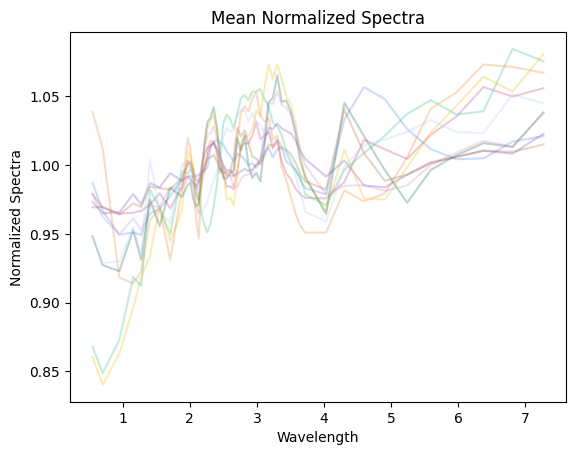

<Figure size 640x480 with 0 Axes>

In [5]:
for i in np.random.choice(len(spectrum), 10):
  plt.plot(wavelengths, spectrum[i]/np.mean(spectrum[i]), alpha=0.3)

plt.title('Mean Normalized Spectra')
plt.ylabel('Normalized Spectra')
plt.xlabel('Wavelength')
plt.show()
plt.savefig('meanspec.png')


In [26]:
sorted_label = label.sort_values(by=['planet_temp', 'log_CO2'])[['planet_ID', 'planet_temp', 'log_CO2']]
sorted_label

,planet_ID,planet_temp,log_CO2
39252,train39253,101.021245,-8.594660
39384,train39385,144.774702,-5.851626
39345,train39346,186.563563,-7.777764
39370,train39371,206.001793,-8.443121
38848,train38849,210.319072,-7.988458
...,...,...,...
38382,train38383,4385.601406,-7.785617
38676,train38677,4421.490499,-8.823015
38506,train38507,4423.873365,-4.327388
38994,train38995,4492.018501,-7.841946


In [34]:
selected_ids = [39259, 38352, 24969, 31268]

In [35]:
sorted_label.loc[selected_ids]

,planet_ID,planet_temp,log_CO2
39259,train39260,309.315380,-7.930684
38352,train38353,310.405033,-4.461754
24969,train24970,1500.050370,-4.609137
31268,train31269,1501.498212,-8.046333


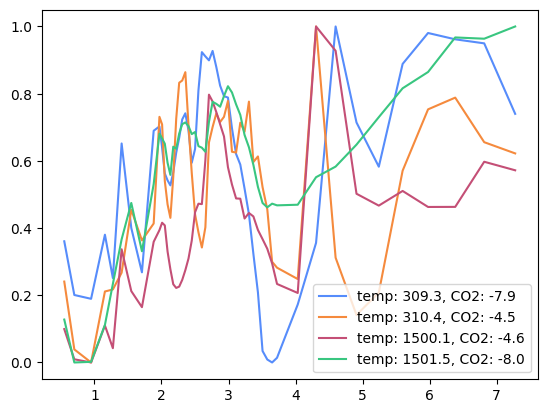

In [41]:
# fig, ax = plt.subplots(2, 2, figsize=(10,10))
# ax = ax.flatten()
# plt.plot(wavelengths, X_norm[selected_ids[0]], label=f'temp: {label.loc[selected_ids[0], "planet_temp"]}, CO2: {label.loc[selected_ids[0], "log_CO2"]}')
# plt.plot(wavelengths, X_norm[selected_ids[1]])
# plt.plot(wavelengths, X_norm[selected_ids[2]])
# plt.plot(wavelengths, X_norm[selected_ids[3]])
for i, spec_id in enumerate(selected_ids):
    plt.plot(wavelengths, X_norm[spec_id], label=f'temp: {label.loc[spec_id, "planet_temp"]:.1f}, CO2: {label.loc[spec_id, "log_CO2"]:.1f}')

plt.legend()

In [22]:
#'planet_radius', 'planet_temp', 'log_H2O','log_CO2', 'log_CO', 'log_CH4', 'log_NH3'
param_names = ['planet_radius', 'planet_temp', 'log_H2O','log_CO2', 'log_CO', 'log_CH4', 'log_NH3']
output = label[param_names].values



In [23]:
def our_min_max(data, axis=1):
  norm_k = (np.max(data, axis=axis) - np.min(data, axis=axis)).reshape(-1,1)
  res = (data - np.min(data, axis=axis).reshape(-1,1))/norm_k
  return res, norm_k

In [24]:
y_scaler = MinMaxScaler()
y_norm = y_scaler.fit_transform(output)
# y_norm, y_k = our_min_max(output, axis=1)

aux_norm = MinMaxScaler().fit_transform(auxill.drop('planet_ID', axis=1))
X_norm, norm_koeffs = our_min_max(spectrum)
# norm_koeffs = (np.max(spectrum, axis=1) - np.min(spectrum, axis=1)).reshape(-1,1)
# unc_norm = unc/norm_koeffs
# X_norm = (spectrum - np.min(spectrum, axis=1).reshape(-1,1))/norm_koeffs

input = np.concatenate((X_norm, aux_norm), axis=1)
input.shape

(41423, 60)

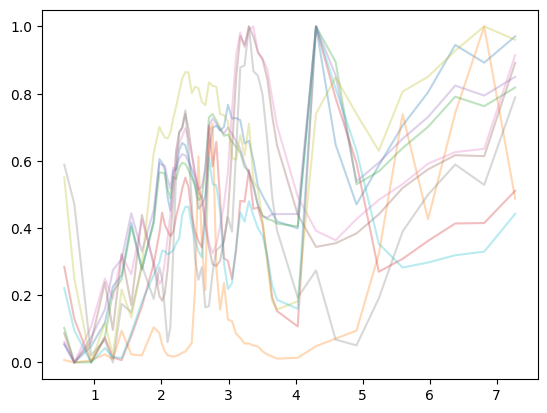

In [ ]:
for i in np.random.choice(len(X_norm), 10):
  plt.plot(wavelengths, X_norm[i], alpha=0.3)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(input, y_norm, test_size=0.1, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=1)

input.shape[1]

60

In [ ]:
callback = keras.callbacks.EarlyStopping(monitor = 'loss', patience=3)
n = output.shape[1]
model = tf.keras.Sequential([tf.keras.Input(shape=(input.shape[1],)),
tf.keras.layers.Dense(200, activation='relu'),
tf.keras.layers.Dense(100, activation='relu'),
tf.keras.layers.Dense(50, activation='relu'),
tf.keras.layers.Dense(n)
])


model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,707 (147.29 KB)

 Trainable params: 37,707 (147.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, validation_data = (X_val, y_val),
          epochs=100, shuffle=True, callbacks=[callback],
          batch_size=200)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0428 - mae: 0.1543 - val_loss: 0.0194 - val_mae: 0.1048
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0169 - mae: 0.0961 - val_loss: 0.0141 - val_mae: 0.0866
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0131 - mae: 0.0821 - val_loss: 0.0112 - val_mae: 0.0750
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0109 - mae: 0.0727 - val_loss: 0.0105 - val_mae: 0.0711
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0095 - mae: 0.0671 - val_loss: 0.0094 - val_mae: 0.0673
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0085 - mae: 0.0625 - val_loss: 0.0076 - val_mae: 0.0598
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0078 - mae: 0.0591 - val_loss: 0.0068 - val_mae: 0.0549
Epoch 8/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0071 - mae: 0.0560 - val_loss: 0.0066 - val_mae: 0.0523
Epoch 9/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5m

In [ ]:

y_pred = model.predict(X_test)


130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
loss, accuracy  = model.evaluate(X_test, y_test)

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0035 - mae: 0.0355


In [ ]:
quality = np.sum((y_pred-y_test)**2, axis=0)/y_test.shape[0]

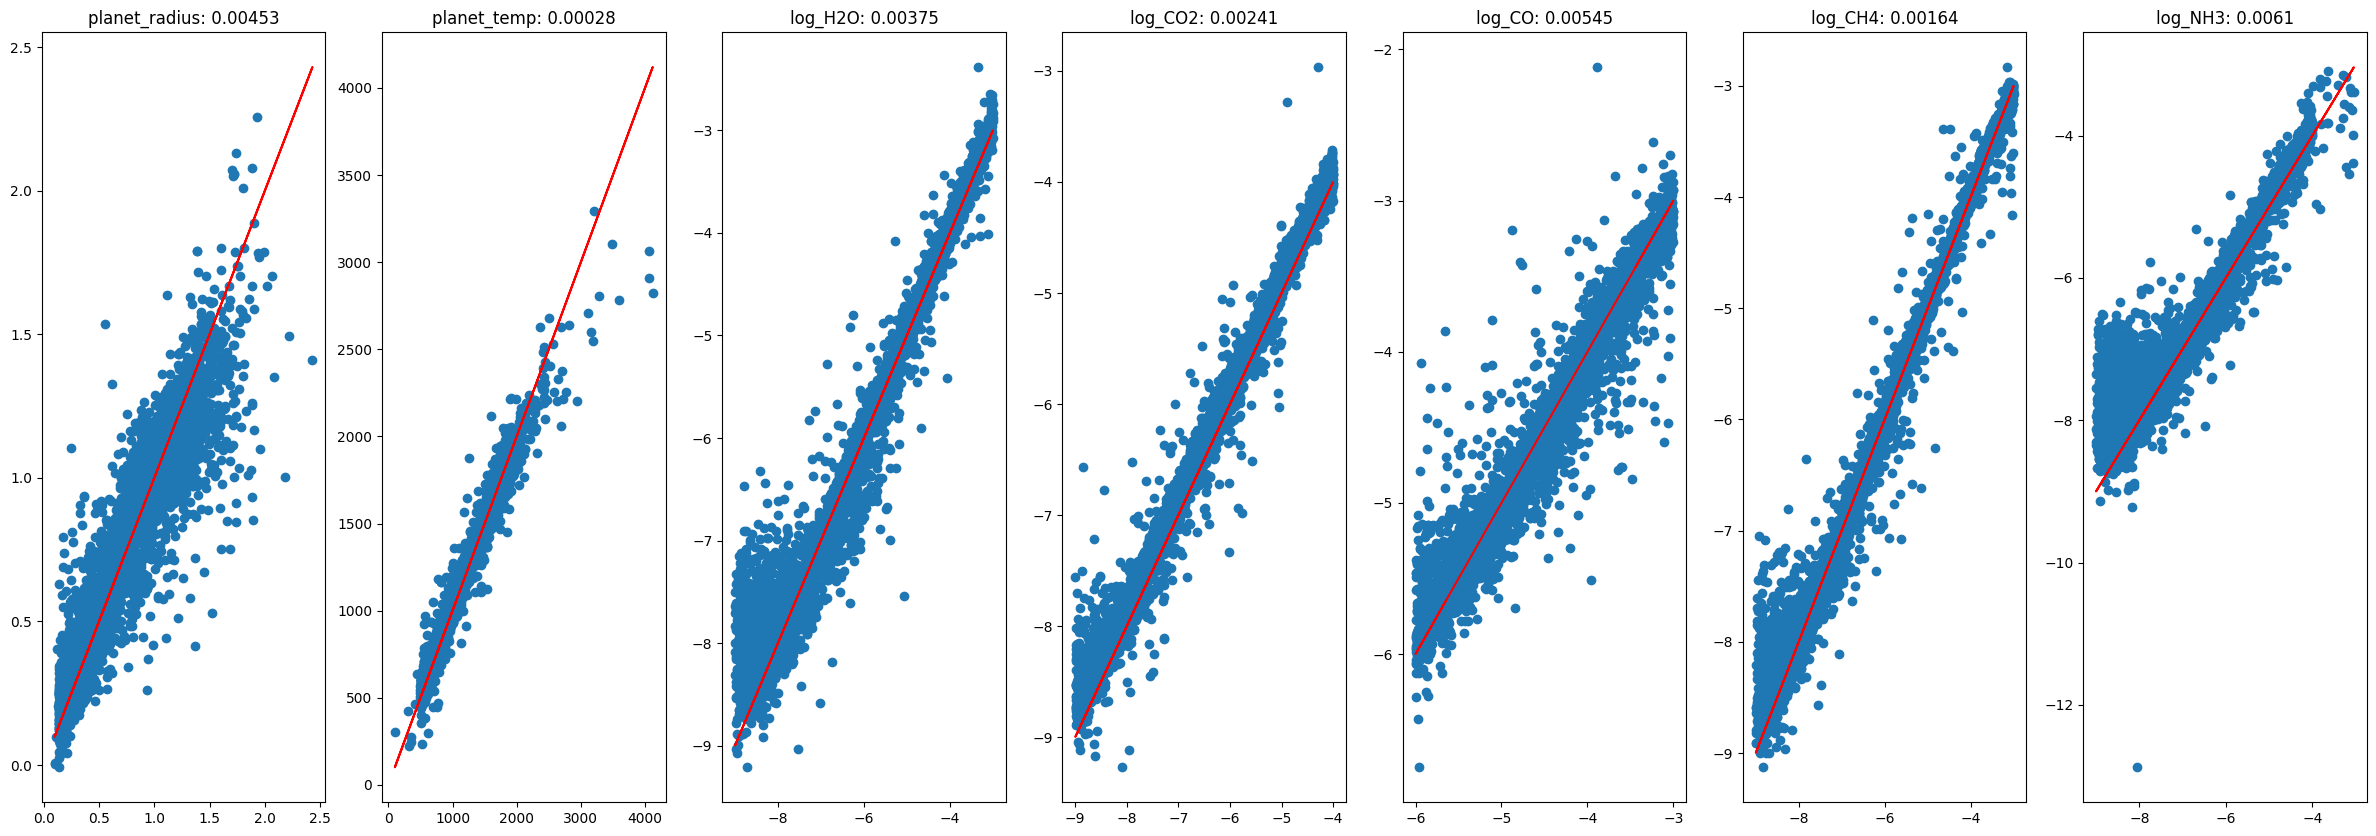

In [ ]:
y_test_phys = y_scaler.inverse_transform(y_test)
y_pred_phys = y_scaler.inverse_transform(y_pred)

# 4 layers
fig, axes = plt.subplots(1, n, figsize=(30,10))
axes_flat = axes.flatten()
for i in range(n):
    axes_flat[i].set_title(f'{param_names[i]}: {np.round(quality[i], 5)}')
    axes_flat[i].scatter(y_test_phys[:,i], y_pred_phys[:,i])
    axes_flat[i].plot(y_test_phys[:,i], y_test_phys[:,i], 'r')

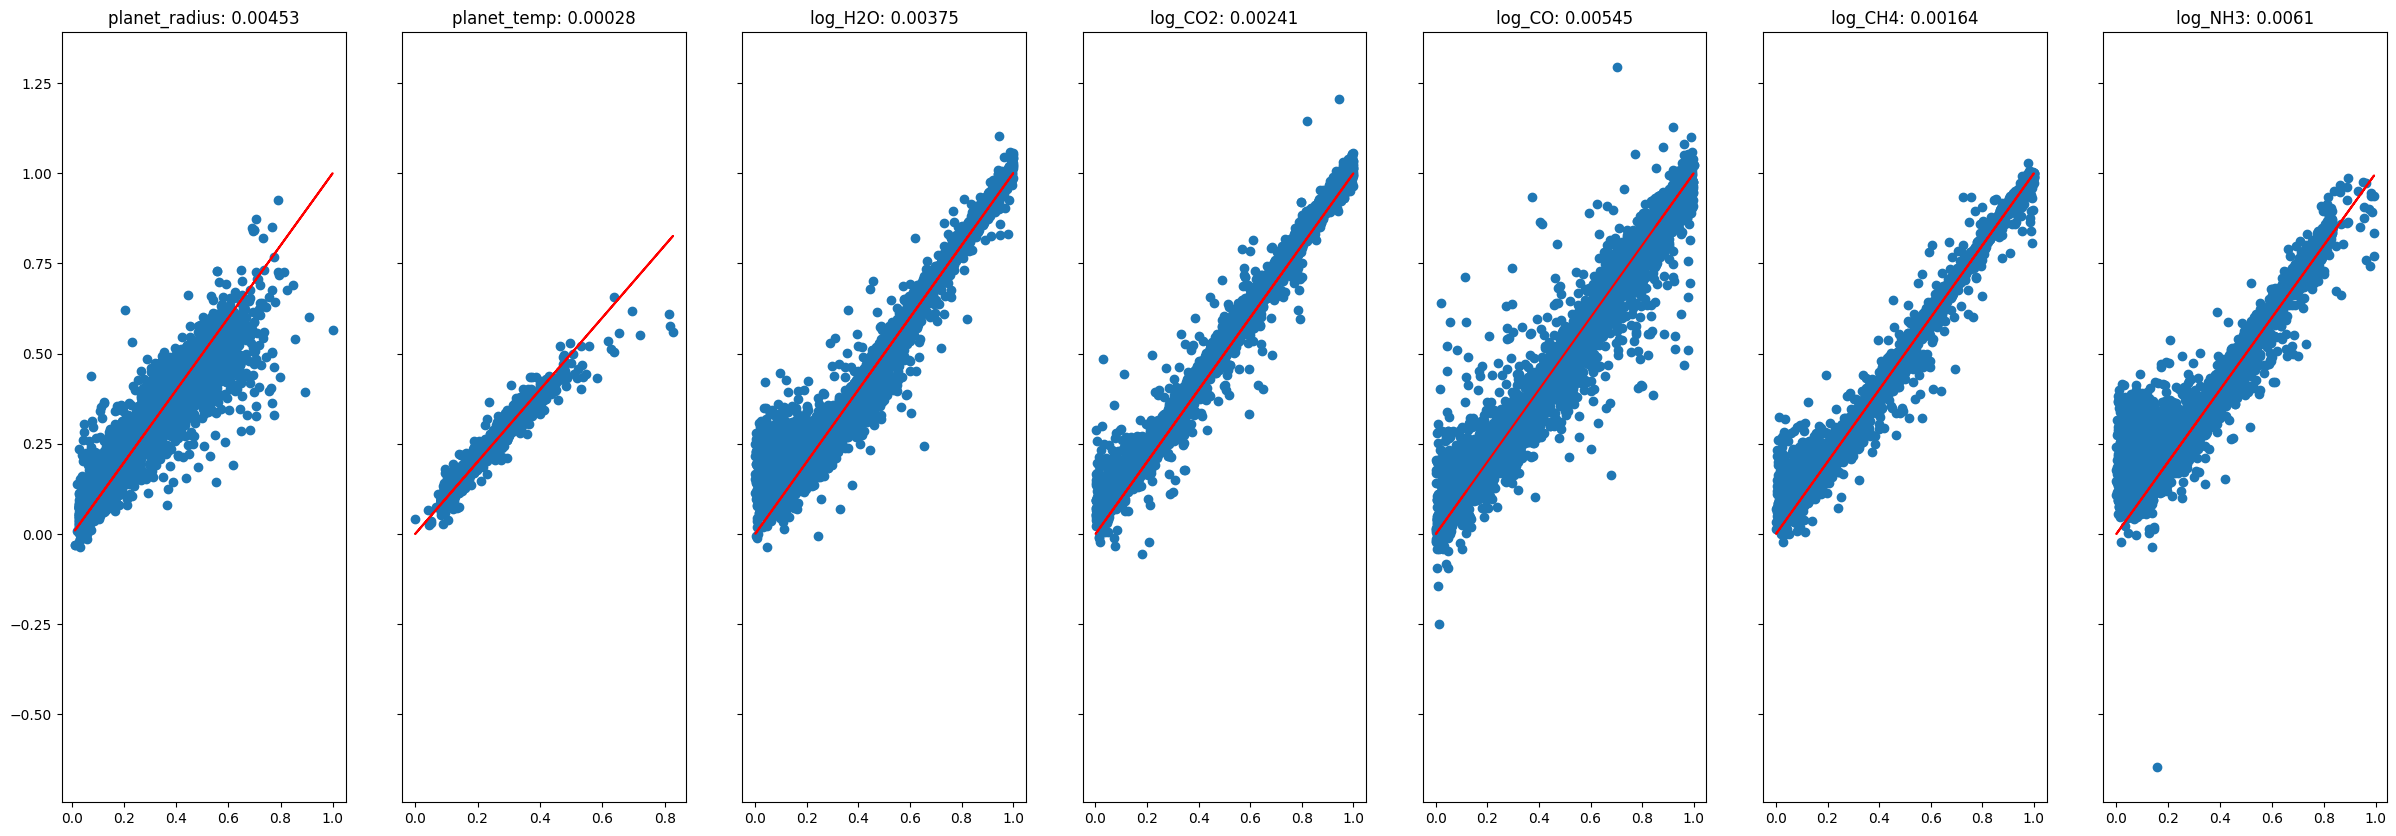

In [ ]:
# 4 layers
fig, axes = plt.subplots(1, n, figsize=(30,10), sharey=True)
axes_flat = axes.flatten()
for i in range(n):
    axes_flat[i].set_title(f'{param_names[i]}: {np.round(quality[i], 5)}')
    axes_flat[i].scatter(y_test[:,i], y_pred[:,i])
    axes_flat[i].plot(y_test[:,i], y_test[:,i], 'r')

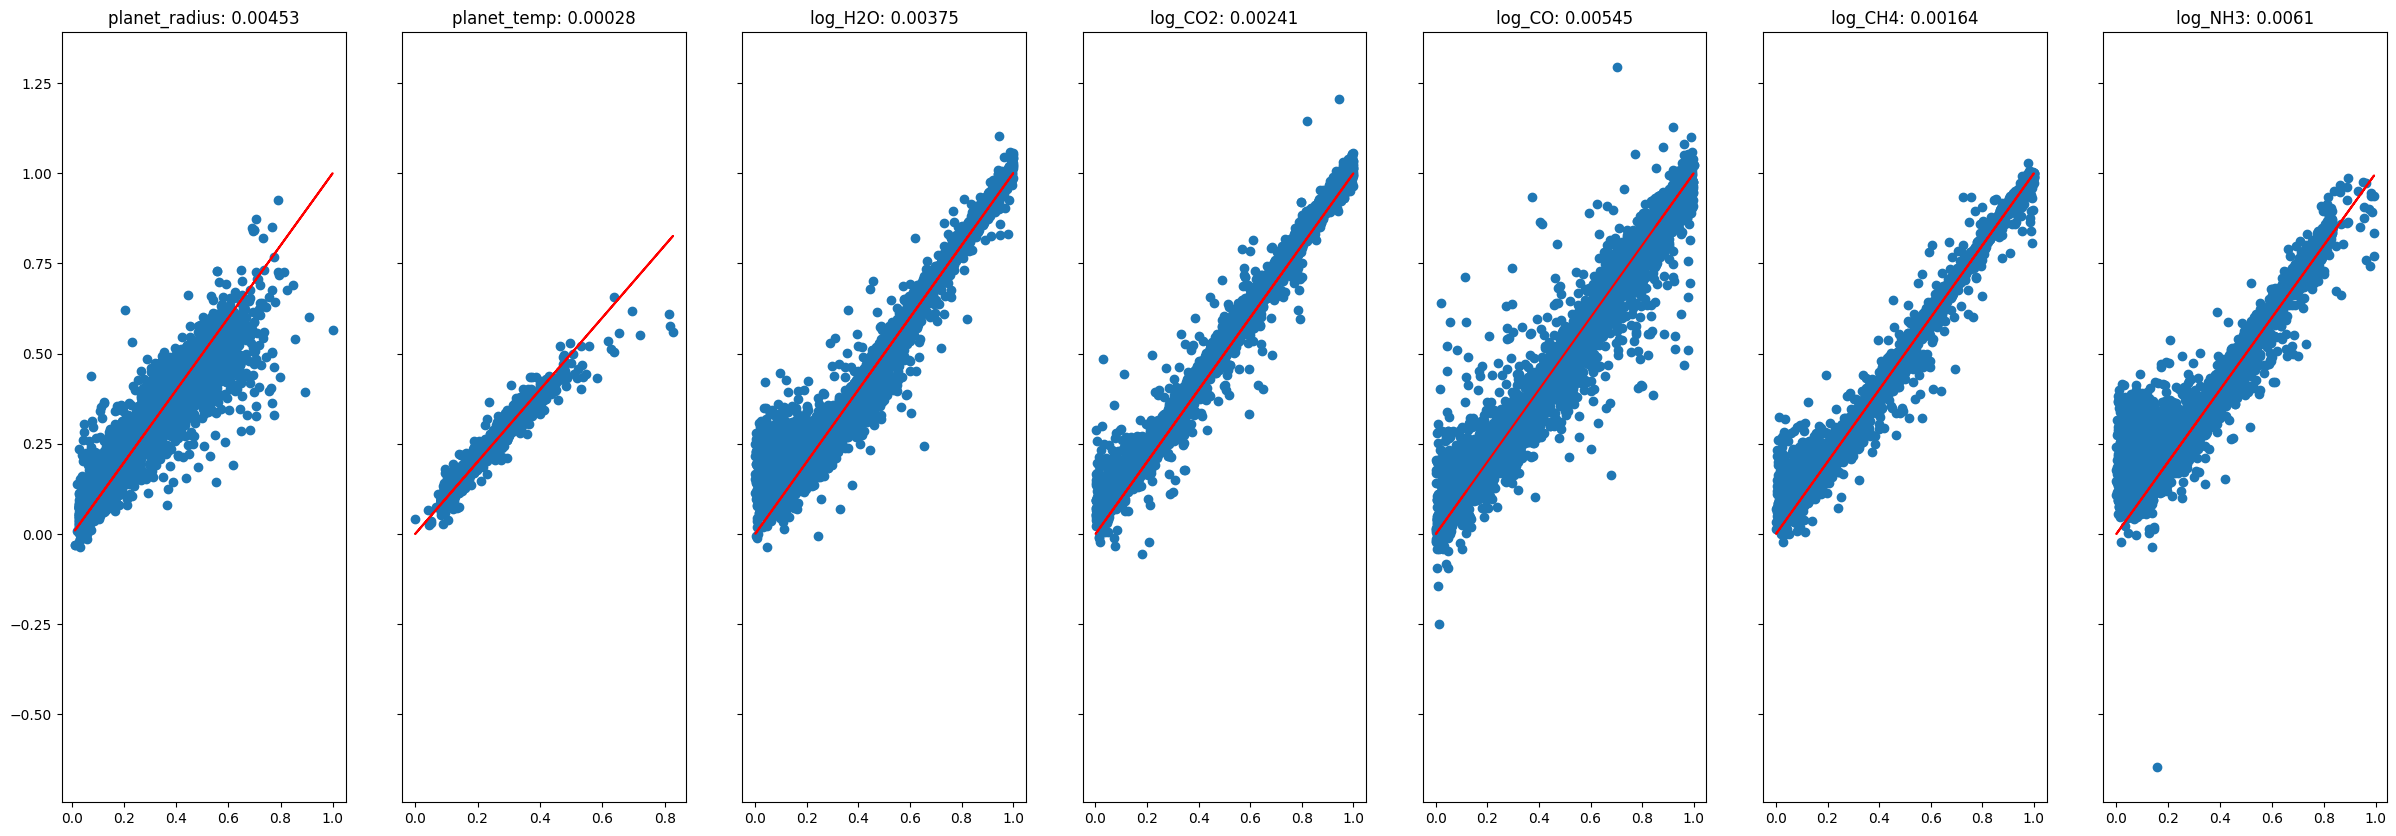

In [ ]:
# Aux + norm + errs
fig, axes = plt.subplots(1, n, figsize=(30,10), sharey=True)
axes_flat = axes.flatten()
for i in range(n):
    axes_flat[i].set_title(f'{param_names[i]}: {np.round(quality[i], 5)}')
    axes_flat[i].scatter(y_test[:,i], y_pred[:,i])
    axes_flat[i].plot(y_test[:,i], y_test[:,i], 'r')

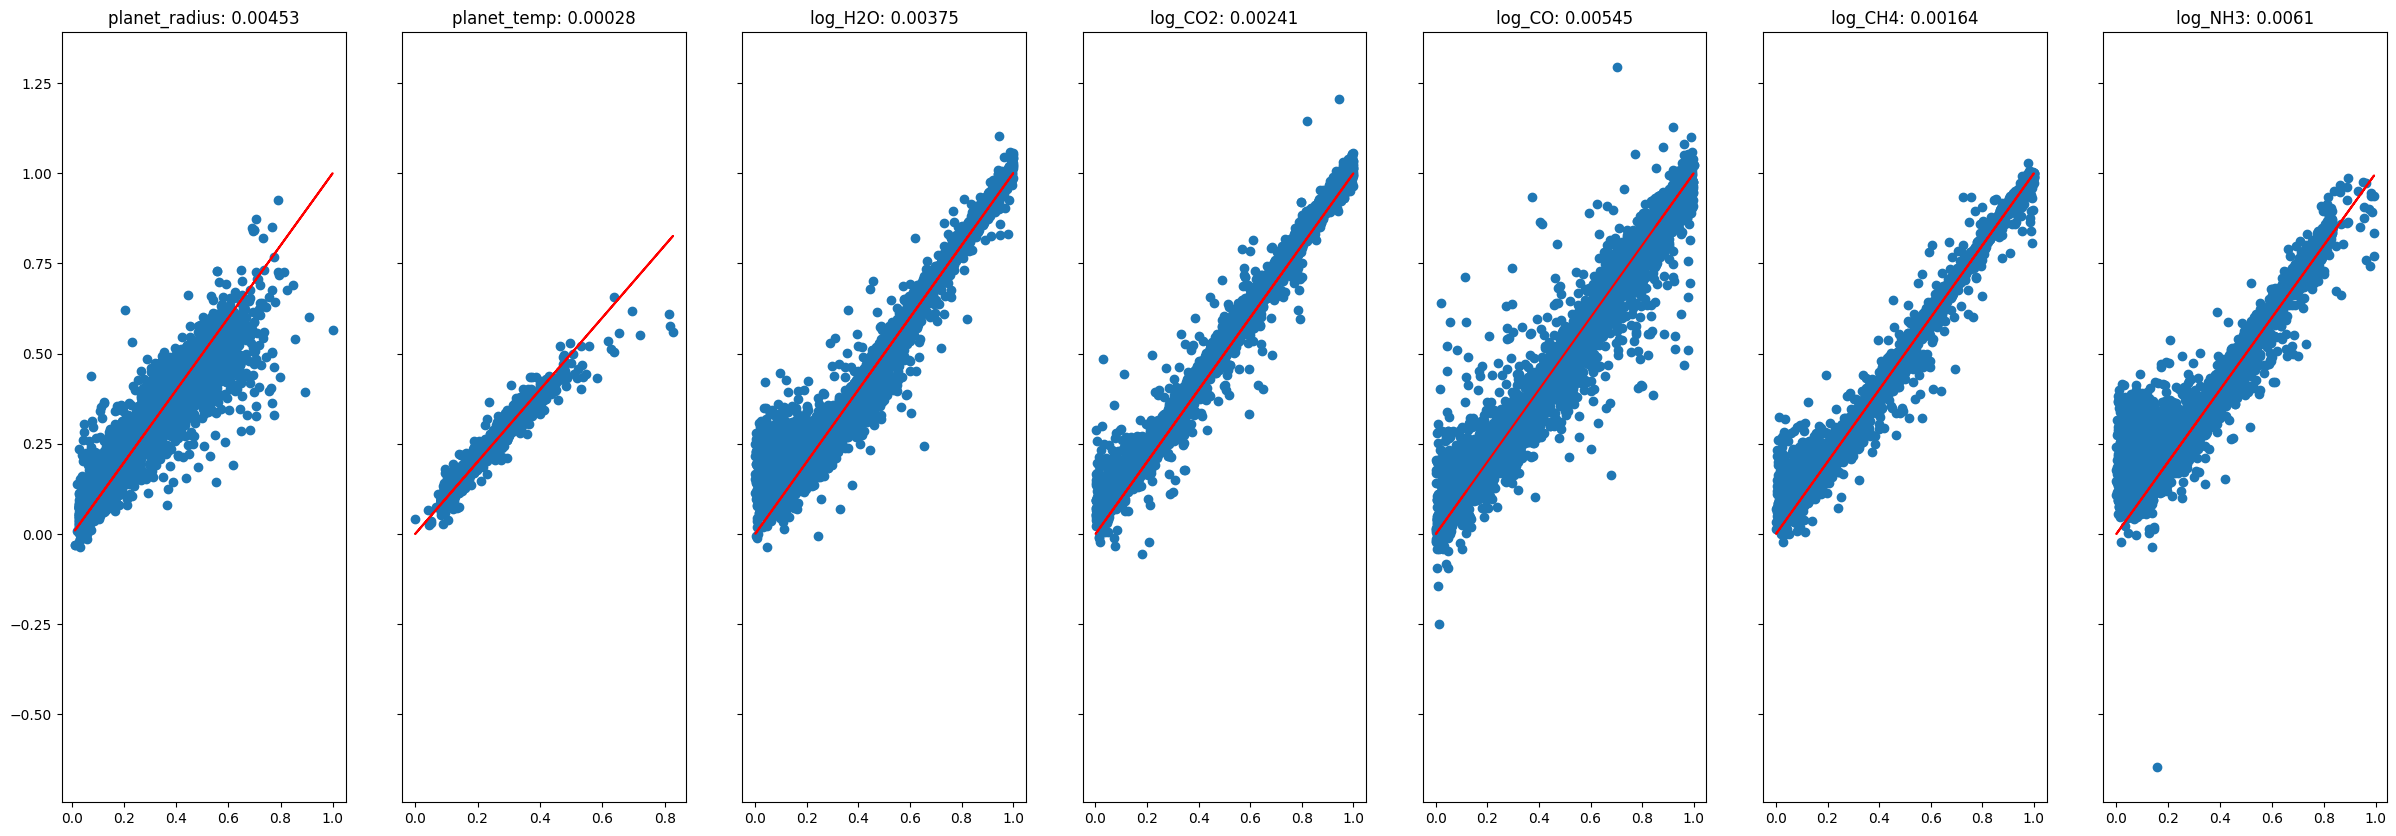

In [ ]:
# Aux + norm
fig, axes = plt.subplots(1, n, figsize=(30,10), sharey=True)
axes_flat = axes.flatten()
for i in range(n):
    axes_flat[i].set_title(f'{param_names[i]}: {np.round(quality[i], 5)}')
    axes_flat[i].scatter(y_test[:,i], y_pred[:,i])
    axes_flat[i].plot(y_test[:,i], y_test[:,i], 'r')


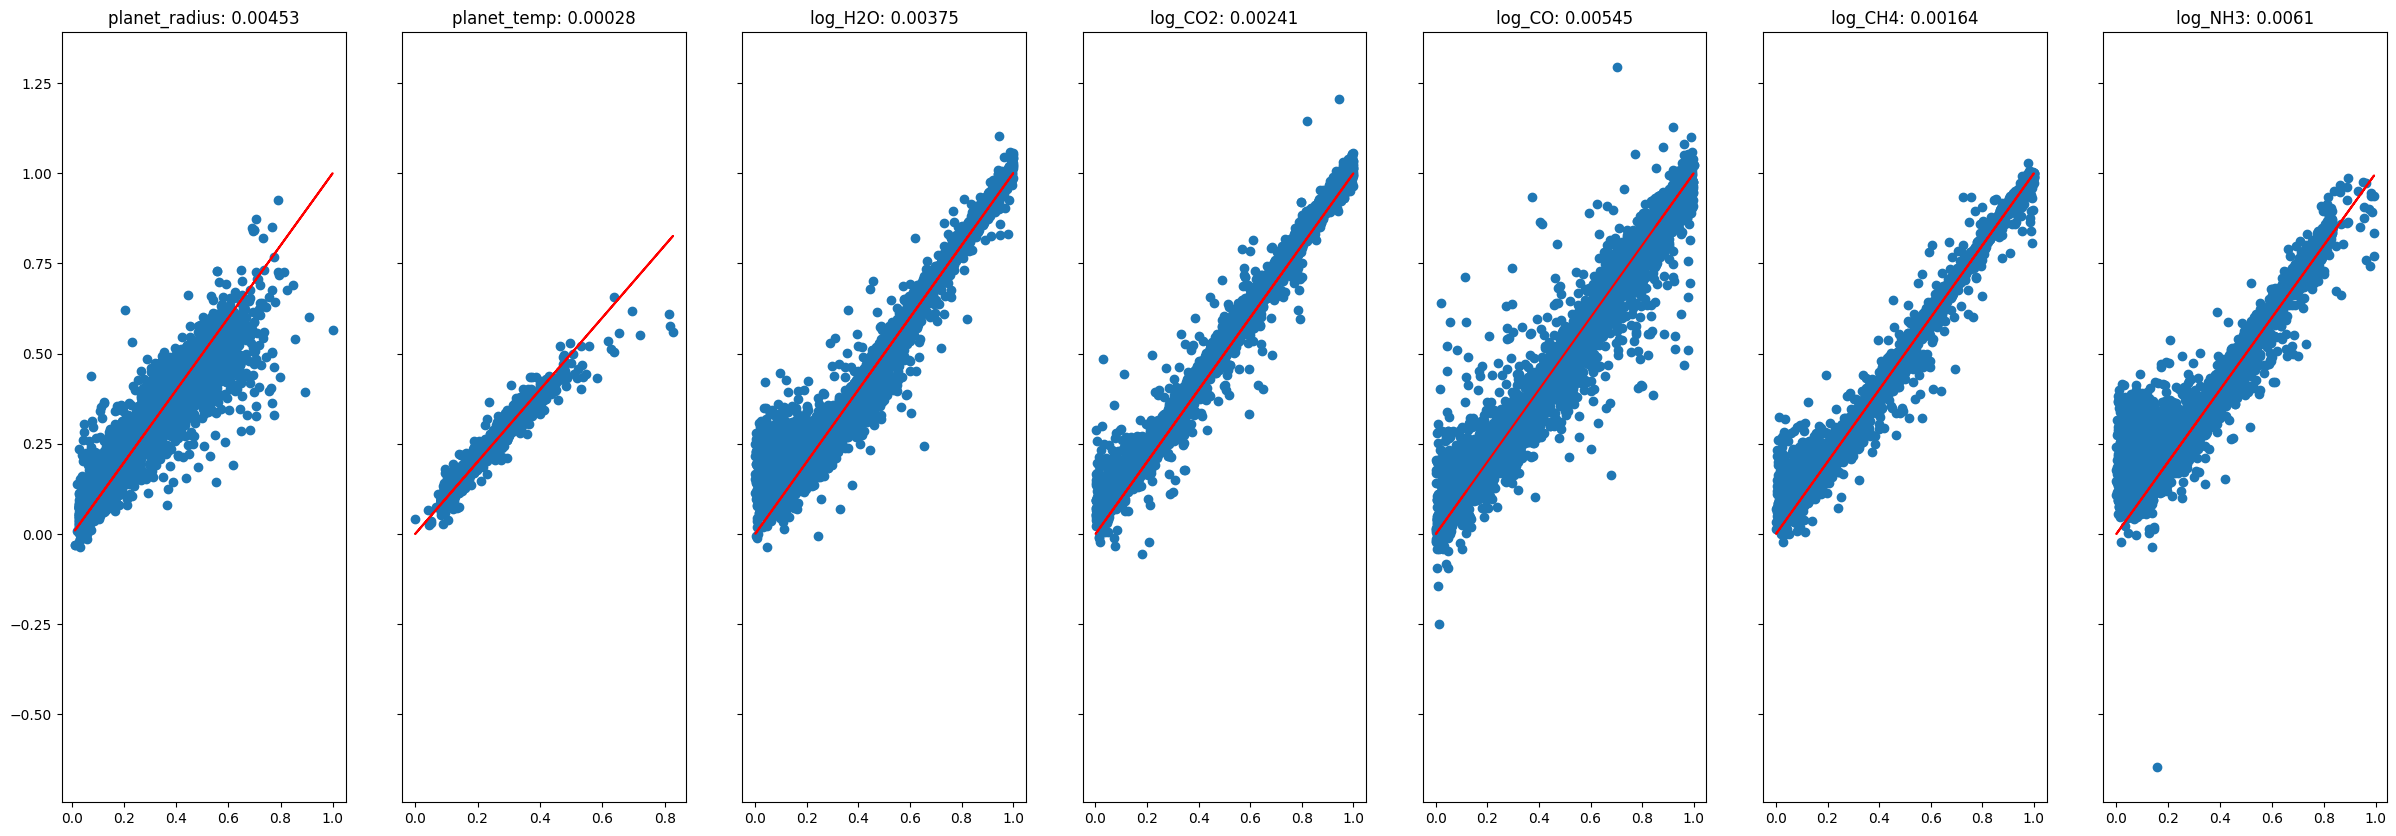

In [ ]:
# Only Aux
fig, axes = plt.subplots(1, n, figsize=(30,10), sharey=True)
axes_flat = axes.flatten()
for i in range(n):
    axes_flat[i].set_title(f'{param_names[i]}: {np.round(quality[i], 5)}')
    axes_flat[i].scatter(y_test[:,i], y_pred[:,i])
    axes_flat[i].plot(y_test[:,i], y_test[:,i], 'r')


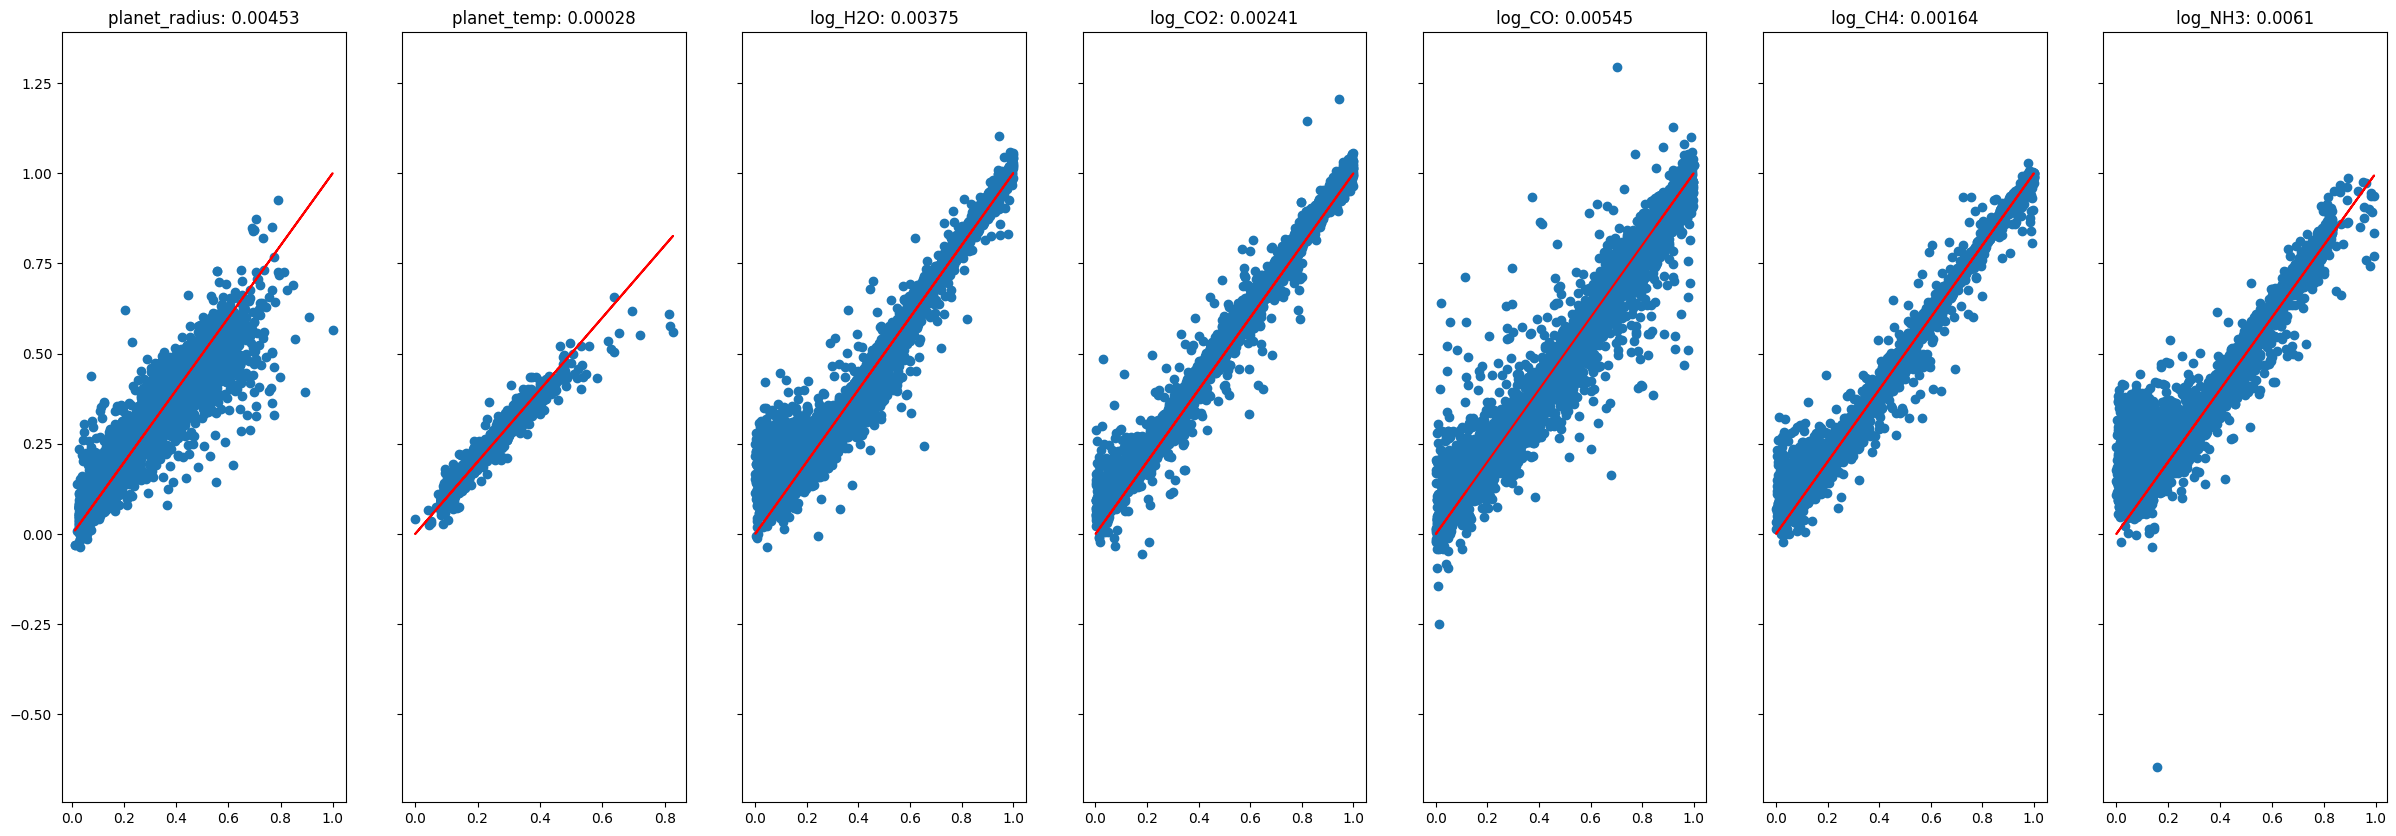

In [ ]:
# Only norm
fig, axes = plt.subplots(1, n, figsize=(30,10), sharey=True)
axes_flat = axes.flatten()
for i in range(n):
    axes_flat[i].set_title(f'{param_names[i]}: {np.round(quality[i], 5)}')
    axes_flat[i].scatter(y_test[:,i], y_pred[:,i])
    axes_flat[i].plot(y_test[:,i], y_test[:,i], 'r')


In [ ]:
np.sum((y_pred-y_test)**2, axis=0)/y_test.shape[0]

#array([0.01184789, 0.00040524, 0.00434872, 0.0016439 , 0.00952857, 0.00198055, 0.00652938])
#array([0.00439043, 0.00285925, 0.00606524, 0.00157287, 0.0052201 ])

array([0.00453324, 0.00028372, 0.00374604, 0.00241088, 0.00544689,
       0.00164298, 0.006102  ])

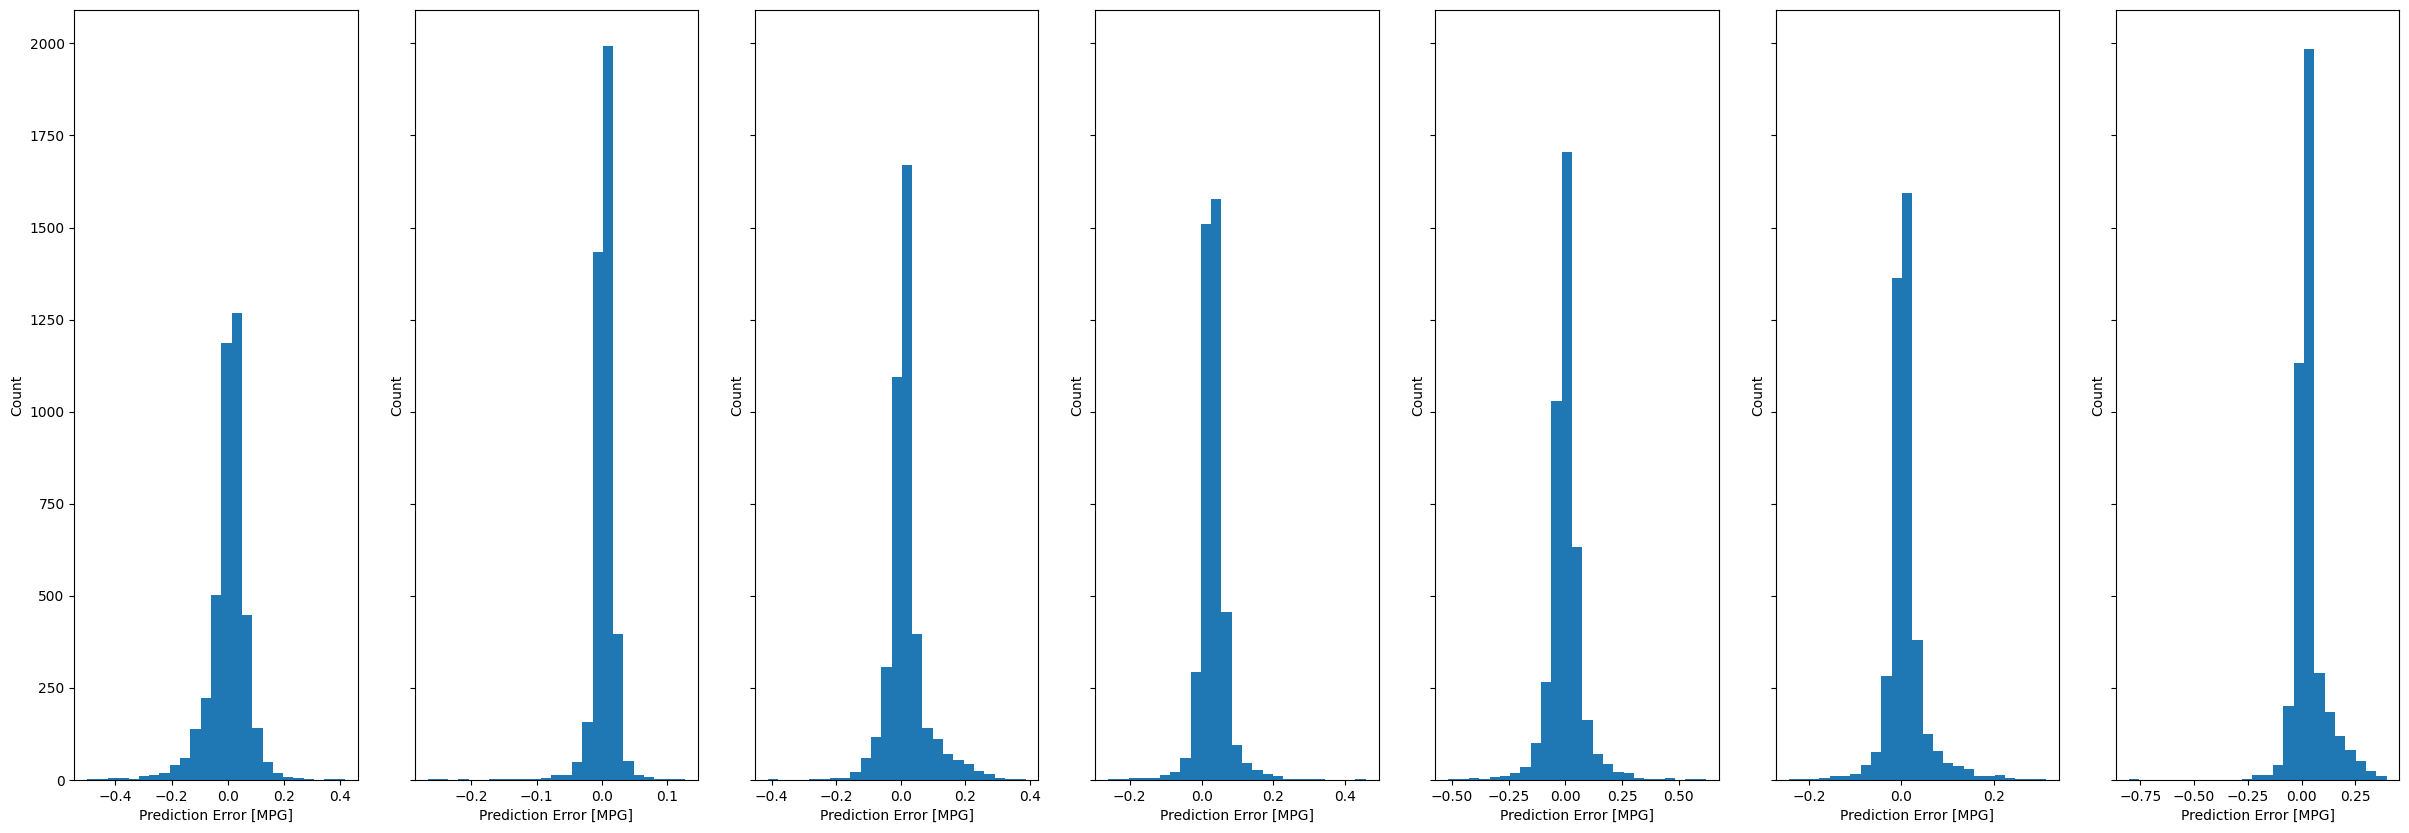

In [ ]:
fig, ax = plt.subplots(1, n, figsize=(30,10), sharey=True)
for i in range(n):
  error = y_pred[:,i] - y_test[:,i]
  ax[i].hist(error, bins=25)
  ax[i].set_xlabel('Prediction Error [MPG]')
  ax[i].set_ylabel('Count')

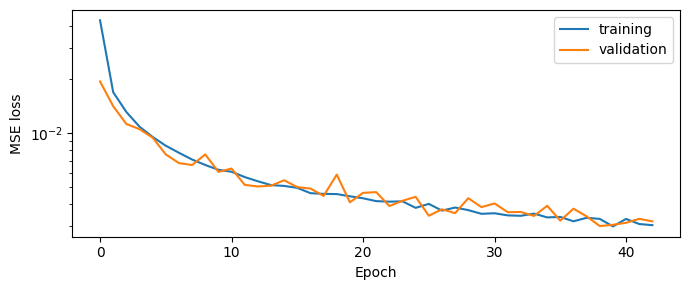

In [ ]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(training_loss, label='training')
ax.plot(validation_loss, label='validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()